# Assignment 5
### Do all four questions.

## Garret Knapp
## nbz3de

**1.** Let's review some basic matrix multiplication. When you have an $M \times N$ matrix $A$ with $M$ rows and $N$ columns, 
$$
A= \left[ \begin{array}{cccc} a_{11} & a_{12} & ... & a_{1N} \\
a_{21} & a_{22} & ... & a_{2N} \\
\vdots & \vdots & ... & \vdots \\
a_{M1} & a_{M2} & ... & a_{MN} 
\end{array} \right],
$$
and you right-multiply it by a vector
$$
x = \left[ \begin{array}{c} x_1 \\ x_2 \\ \vdots \\ x_N 
\end{array} \right],
$$
you get
$$
Ax = \left[ \begin{array}{c} \sum_{i=1}^N a_{1i} x_i \\ \sum_{i=1}^N a_{2i} x_i \\ \vdots \\ \sum_{i=1}^N a_{Mi} x_i 
\end{array} \right].
$$
This is just "matrix row times column vector" element-by-element, stacking the results into a new vector.

For this to make sense, $N$ must be the same for the matrix and the vector, but $M$ can be different from $N$. 

Let's play with some NumPy to see this. First we'll define a matrix $A$:

In [1]:
import numpy as np

A = np.array([ [1,2,3],
              [4,5,6],
              [7,8,9]])
A

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

a. Multiply $A$ times each of the following vectors using the @ operator. Explain which part of the $A$ matrix gets selected and explain why, using the definition of matrix multiplication. 

In [2]:
e_1 = np.array([1,0,0])
e_2 = np.array([0,1,0])
e_3 = np.array([0,0,1])

In [3]:
result1 =  A @ e_1
result1

array([1, 4, 7])

In [4]:
result2 = A @ e_2
result2

array([2, 5, 8])

In [5]:
result3 = A @ e_3
result3

array([3, 6, 9])

When you multiply matrix **A** by each of these vectors using the `@` operator, you're selecting individual columns of the matrix. The vectors `e_1 = [1,0,0]`, `e_2 = [0,1,0]`, and `e_3 = [0,0,1]` act as "column pickers" because they have a 1 in one position and 0s everywhere else. By the definition of matrix multiplication, when you multiply A by a vector with a single 1 in position k and 0s elsewhere, the 0s cancel out all other columns and the 1 keeps only column k, so `A @ e_1` gives you the first column, `A @ e_2` gives you the second column, and `A @ e_3` gives you the third column.

b. Now multiply $A$ times $u = (1,1,1)$. Explain the logic of the result with the definition of matrix multiplication.

In [6]:
u = np.ones(3)
u

array([1., 1., 1.])

In [7]:
result_b = A @ u
result_b

array([ 6., 15., 24.])

When you multiply `A` times `u = (1, 1, 1)`, you're computing the sum of all three columns of matrix A. 

By the definition of matrix multiplication, each element of the result is the dot product of a row of `A` with the vector `u`. Since `u` has all 1s, when you compute the dot product of any row with `u`, you're doing: `row[0]×1 + row[1]×1 + row[2]×1`, which simply adds up all three elements in that row. This happens for each row independently, giving you a result where each element is the sum of the corresponding row.

c. Whenever a matrix has 1's on the diagonal and zeros everywhere else, we call it an **identity matrix**. What happens when you multiple $A$ times $x$ below? What happens when you multiple an identity matrix times any vector? Explain your result with the definition of matrix multiplication.

In [8]:
A = np.array([ [1,0,0],
              [0,1,0],
              [0,0,1]])
x = np.array([-2,4,11])
A @ x

array([-2,  4, 11])

When you multiply the identity matrix `A` times the vector `x = [-2, 4, 11]`, you get `x` back unchanged: `[-2, 4, 11]`.

When you multiply an identity matrix times any vector, you always get that same vector back unchanged. The identity matrix acts like "multiplying by 1" - it doesn't change anything.

Using the definition of matrix multiplication: Each element of the result is the dot product of a row of the identity matrix with vector `x`. For example, the first row `[1, 0, 0]` dotted with `[-2, 4, 11]` gives `1×(-2) + 0×4 + 0×11 = -2`. The second row `[0, 1, 0]` dotted with `x` gives `0×(-2) + 1×4 + 0×11 = 4`. The third row `[0, 0, 1]` dotted with `x` gives `0×(-2) + 0×4 + 1×11 = 11`. Each row picks out exactly one element from the vector (the element at the position where the 1 appears), so you reconstruct the original vector.

d. What if every row and column sum to 1, but the 1's are no longer on the diagonal? Multiple $A$ times $X$ below and explain the result. Create another matrix whose rows and columns sum to 1, but is not an identity matrix, and show how it permutes the values of $x$. 

In [9]:
A = np.array([ [0,0,1],
              [1,0,0],
              [0,1,0]])
x = np.array([-2,4,11])

A @ x


array([11, -2,  4])



This happens because the 1’s in the matrix are not on the diagonal.
Each row still selects one element from `x`, but in a different order, so the result is a permutation of the vector.
A permutation matrix rearranges the positions of elements in `x` rather than changing their values.
Therefore, multiplying by a matrix whose rows and columns each sum to 1—but that is not the identity matrix—results in a reordering of the original vector.



In [10]:
A = np.array([ [1,0,0],
              [0,0,1],
              [0,1,0]])
x = np.array([-2,4,11])

A @ x

array([-2, 11,  4])

This supports the permutation described above, as the values remained unchanged but the order of the values has been rearranged.

e. The next matrix $A$ could be a Markov transition matrix: Its columns sum to 1, and each entry $a_{ij}$ can be interpreted as the proportion of observations who moved from state $j$ to state $i$. Multiply $A$ by each of the vectors $e_1$, $e_2$, and $e_3$, and explain your results.

In [11]:
rng = np.random.default_rng(100)
A = rng.random((3,3)) # Generate a random 3X3 matrix
sums = np.sum(A,axis=0) # Column sums
A = A/sums # Normalize the columns so they sum to 1
print(A)

[[0.50052958 0.24049286 0.18358131]
 [0.02574731 0.39251588 0.37907577]
 [0.47372311 0.36699127 0.43734292]]


In [12]:
A @ e_1

array([0.50052958, 0.02574731, 0.47372311])

In [13]:
A @ e_2

array([0.24049286, 0.39251588, 0.36699127])

In [14]:
A @ e_3

array([0.18358131, 0.37907577, 0.43734292])

When `A` is multiplied by `e₁`, `e₂`, and `e₃`, each result gives the transition probabilities from state 1, 2, and 3 respectively to all states. The i-th entry in each result vector represents the probability of ending up in state i.

For example, the result of `A @ e_1` — `[0.50052958, 0.02574731, 0.47372311]` — represents the probabilities of transitioning from State 1 to States 1, 2, and 3, respectively.


f. For each of the vectors $e_1, e_2, e_3$, multiple $A$ times that vector 5 times. What answer do you get for each starting vector? Describe the behavior you observe.

In [15]:
for i in range(0,5):
    e_1 = A @ e_1
    print(e_1)
e_1

[0.50052958 0.02574731 0.47372311]
[0.34368862 0.20257047 0.45374091]
[0.30404142 0.26036337 0.43559521]
[0.29476439 0.27514859 0.43008701]
[0.29266551 0.27862515 0.42870935]


array([0.29266551, 0.27862515, 0.42870935])

In [16]:
for i in range(0,5):
    e_2 = A @ e_2
    print(e_2)
e_2

[0.24049286 0.39251588 0.36699127]
[0.28214379 0.29937825 0.41847795]
[0.29004438 0.28341002 0.42654561]
[0.29163968 0.2804039  0.42795643]
[0.29197422 0.27979983 0.42822595]


array([0.29197422, 0.27979983, 0.42822595])

In [17]:
for i in range(0,5):
    e_3 = A @ e_3
    print(e_3)
e_3

[0.18358131 0.37907577 0.43734292]
[0.26334088 0.31930609 0.41735304]
[0.28521895 0.29032145 0.4244596 ]
[0.29050361 0.28220175 0.42729464]
[0.29171646 0.2802254  0.42805814]


array([0.29171646, 0.2802254 , 0.42805814])

After multiplying `A` by each vector 5 times, all three vectors converge to approximately the same distribution: `[0.29, 0.28, 0.43]`. This demonstrates that regardless of the starting state, the Markov chain approaches a steady-state distribution where the long-term probabilities become independent of the initial state.

*2.* Let's consider a simple Markov transition matrix over two states:
$$
T = \left[ \begin{array}{cc} p_{1\leftarrow 1} &  p_{1\leftarrow 2} \\
p_{2 \leftarrow 1} & p_{2 \leftarrow 2} \end{array}\right] 
$$
The arrows help visualize the transition a bit: This is the same index notation as usual, $p_{ij}$, but writing it $p_{i \leftarrow j}$ emphasizes that it's the proportion of times that state $j$ transitions to state $i$. Below, $T$ is given by
$$
T = \left[ \begin{array}{cc} .25 & .5 \\
.75 & .5 \end{array}\right].
$$

- Start in state 1, at the initial condition $[1,0]$. Multiply that vector by $T$. Write out the result in terms of the formula and compute the result in a code chunk below. What is this object you're looking at, in terms of proportions and transitions?
- Multiple by $T$ again. What do you get? This isn't a column of $T$. Explain in words what it is. (Hint: A forecast of what in what period?)
- Keep multiplying the current vector of outcomes by $T$. When does it start to settle down without changing further?
- Do the above analysis again, starting from the initial condition $[0,1]$. Do you get a different result?
- The take-away is that, in the long run, these chains settle down into the long-run proportions, and the sensitivity on initial conditions vanishes. 


In [18]:
T = np.array([[ 1/4, 1/2],
                 [ 3/4, 1/2 ]])

initial = np.array([1, 0])

result_step1 = T @ initial
print("Step 1 result:", result_step1)



Step 1 result: [0.25 0.75]


This result is the first column of the transition matrix T. In terms of proportions and transitions, this represents the probability distribution of being in each state after one time step, given a start in state 1. It shows the proportion of times transitioning from state 1 to each possible state (in this case only itself and state 2) occurs.

In [19]:
result_step2 = T @ result_step1
print("Step 2 result:", result_step2)


Step 2 result: [0.4375 0.5625]


Multiplying the previous result by T again gives the forecast for period 2. This is not simply a column of T - instead, it represents the probability distribution of being in each state after two time steps starting from state 1. This accounts for all possible two-step transition paths: going from state 1 to state 1 and then to either state, or from state 1 to state 2 and then to either state. Each path is weighted by its probability, giving the combined forecast for the location after two transitions.

In [20]:
for i in range(1,20):
    initial = T @ initial
    print(f"{i} Values: {initial}")

1 Values: [0.25 0.75]
2 Values: [0.4375 0.5625]
3 Values: [0.390625 0.609375]
4 Values: [0.40234375 0.59765625]
5 Values: [0.39941406 0.60058594]
6 Values: [0.40014648 0.59985352]
7 Values: [0.39996338 0.60003662]
8 Values: [0.40000916 0.59999084]
9 Values: [0.39999771 0.60000229]
10 Values: [0.40000057 0.59999943]
11 Values: [0.39999986 0.60000014]
12 Values: [0.40000004 0.59999996]
13 Values: [0.39999999 0.60000001]
14 Values: [0.4 0.6]
15 Values: [0.4 0.6]
16 Values: [0.4 0.6]
17 Values: [0.4 0.6]
18 Values: [0.4 0.6]
19 Values: [0.4 0.6]


After about 14 transitions the values begin to converge to the same `[0.4 0.6]` values


In [21]:
T = np.array([[ 1/4, 1/2],
                 [ 3/4, 1/2 ]])

initial = np.array([0, 1])

result_step1 = T @ initial
print("Step 1 result:", result_step1)

result_step2 = T @ result_step1
print("Step 2 result:", result_step2)

for i in range(1,20):
    initial = T @ initial
    print(f"{i} Values: {initial}")

Step 1 result: [0.5 0.5]
Step 2 result: [0.375 0.625]
1 Values: [0.5 0.5]
2 Values: [0.375 0.625]
3 Values: [0.40625 0.59375]
4 Values: [0.3984375 0.6015625]
5 Values: [0.40039062 0.59960938]
6 Values: [0.39990234 0.60009766]
7 Values: [0.40002441 0.59997559]
8 Values: [0.3999939 0.6000061]
9 Values: [0.40000153 0.59999847]
10 Values: [0.39999962 0.60000038]
11 Values: [0.4000001 0.5999999]
12 Values: [0.39999998 0.60000002]
13 Values: [0.40000001 0.59999999]
14 Values: [0.4 0.6]
15 Values: [0.4 0.6]
16 Values: [0.4 0.6]
17 Values: [0.4 0.6]
18 Values: [0.4 0.6]
19 Values: [0.4 0.6]


The first initial transition values differ, but similar to the exploration above it settles in the `[04 0.6]` values after about 14 transitions.

3. Weather data

- Load the `cville_weather.csv` data. This includes data from Jan 4, 2024 to Feb 2, 2025. Are there any missing data issues?
- Based on the precipitation variable, `PRCP`, make a new variable called `rain` that takes the value 1 if `PRCP`>0 and 0 otherwise.
- Build a two-state Markov chain over the states 0 and 1 for the `rain` variable. 
- For your chain from c, how likely is it to rain if it was rainy yesterday? How likely is it to rain if it was clear yesterday?
- Starting from a clear day, forecast the distribution. How quickly does it converge to a fixed result? What if you start from a rainy day?
- Conditional on being rainy, plot a KDE of the `PRCP` variable.
- Describe one way of making your model better for forecasting and simulation the weather.

Congratulations, you now are a non-parametric meteorologist!

### Missing Data

In [22]:
import numpy as np
import pandas as pd

weather = pd.read_csv("cville_weather.csv")

print("Missing Values")
for i in weather.columns:
    print(f"{i}")
    print(f"Total Vals: {weather[i].size}")
    print(f"Missing Vals: {weather[i].isna().sum()}")
    print(f"Percent Missing: {(weather[i].isna().sum() / weather[i].size) * 100}")

    print()
# This returns a boolean Series where True indicates a duplicate entry 
# (i.e., its value has appeared before in the column)


Missing Values
STATION
Total Vals: 411
Missing Vals: 0
Percent Missing: 0.0

NAME
Total Vals: 411
Missing Vals: 0
Percent Missing: 0.0

DATE
Total Vals: 411
Missing Vals: 0
Percent Missing: 0.0

DAPR
Total Vals: 411
Missing Vals: 399
Percent Missing: 97.08029197080292

DAPR_ATTRIBUTES
Total Vals: 411
Missing Vals: 399
Percent Missing: 97.08029197080292

MDPR
Total Vals: 411
Missing Vals: 399
Percent Missing: 97.08029197080292

MDPR_ATTRIBUTES
Total Vals: 411
Missing Vals: 399
Percent Missing: 97.08029197080292

PRCP
Total Vals: 411
Missing Vals: 12
Percent Missing: 2.9197080291970803

PRCP_ATTRIBUTES
Total Vals: 411
Missing Vals: 12
Percent Missing: 2.9197080291970803

SNOW
Total Vals: 411
Missing Vals: 188
Percent Missing: 45.742092457420924

SNOW_ATTRIBUTES
Total Vals: 411
Missing Vals: 188
Percent Missing: 45.742092457420924

SNWD
Total Vals: 411
Missing Vals: 410
Percent Missing: 99.7566909975669

SNWD_ATTRIBUTES
Total Vals: 411
Missing Vals: 410
Percent Missing: 99.7566909975669



In [23]:
print(weather['DATE'].max())
print(weather['DATE'].min())
print(len(weather['DATE'].values))

2025-09-28
2024-01-04
411


After loading the `cville_weather.csv` dataset, there appears to be a substantial amount of missing data across most variables. However, the precipitation variable (`PRCP`), which is the focus of this analysis, is only missing 12 observations. Therefore, while the dataset as a whole has quality issues, `PRCP` remains mostly complete and suitable for further analysis.

Because the percentage of missing `PRCP` values is very low and the variable is binary (rain = 1, no rain = 0), I will simply drop the rows with missing values rather than attempt interpolation or averaging.

Additionally, there are missing days as the data is not entirely sequential. There are only 399 days in the dataset but the time span is well over a year and a half indicating missing days in the data. This represents an issue because modeling accurate state transitions is difficult without complete daily data, as Markov chains assume each transition represents consecutive time steps.


### Rain Variable

In [24]:
# drop missing values and convert
weather = weather.dropna(subset=["PRCP"])
weather["rain"] = (weather["PRCP"] > 0).astype(int)


In [25]:
# 1. Identify all rows where the 'DATE' value is duplicated
is_duplicate_date = weather.duplicated(subset=['DATE'], keep=False)

# 2. Filter the DataFrame to show only these rows
duplicate_date_rows = weather[is_duplicate_date].sort_values(by="DATE")

print("--- Duplicate Rows (Based on 'DATE' only) ---")
print(duplicate_date_rows[["DATE", "rain"]])

rain_consistency = duplicate_date_rows.groupby('DATE')['rain'].agg(
    count_occurrences='size',
    unique_rain_values='nunique'
).reset_index()

print("\n--- 'rain' Value Consistency Check ---")
print(rain_consistency)

# Filter the consistency check to show only the dates where 'rain' was inconsistent
dates_with_different_rain = rain_consistency[rain_consistency['unique_rain_values'] > 1]

if dates_with_different_rain.empty:
    print("\n All duplicate 'DATE' entries share the exact same 'rain' value.")
else:
    print("\n These dates have DIFFERENT 'rain' values across their duplicate entries:")
    print(dates_with_different_rain)

--- Duplicate Rows (Based on 'DATE' only) ---
           DATE  rain
7    2024-01-27     0
279  2024-01-27     0
280  2024-01-28     1
8    2024-01-28     1
9    2024-01-29     1
..          ...   ...
194  2024-10-02     1
377  2024-10-03     1
195  2024-10-03     1
196  2024-10-04     1
378  2024-10-04     1

[174 rows x 2 columns]

--- 'rain' Value Consistency Check ---
          DATE  count_occurrences  unique_rain_values
0   2024-01-27                  2                   1
1   2024-01-28                  2                   1
2   2024-01-29                  2                   1
3   2024-01-31                  2                   2
4   2024-02-03                  2                   1
..         ...                ...                 ...
82  2024-09-30                  2                   1
83  2024-10-01                  2                   1
84  2024-10-02                  2                   1
85  2024-10-03                  2                   1
86  2024-10-04                  

In [26]:
## Clean Duplicates 
cleaned_weather = weather.groupby('DATE').agg(
    # Keep the maximum 'rain' value
    rain=('rain', 'max'))

cleaned_weather = cleaned_weather.sort_values(by='DATE', ascending=True)
seq = cleaned_weather['rain'].values
print(seq)
print(cleaned_weather)

[1 1 0 1 1 1 0 0 1 0 0 0 1 1 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 1
 0 0 0 0 0 1 1 0 0 1 0 1 1 1 0 0 0 0 1 0 0 1 1 1 1 1 0 0 0 0 1 0 0 0 1 0 0
 0 1 1 1 1 0 0 0 1 1 0 1 1 1 0 1 1 0 0 0 0 1 0 1 0 1 1 0 0 0 0 1 1 1 1 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 1 1 1
 0 1 1 1 1 1 1 1 0 0 0 1 1 0 0 1 1 1 1 0 0 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 1 0 0 1 0 0 0 1 1 1 1 1 1 1 0 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0
 1 1 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
            rain
DATE            
2024-01-04     1
2024-01-07     1
2024-01-08     0
2024-01-09     1
2024-01-10     1
...          ...
2025-09-18     1
2025-09-21     1
2025-09-25     1
2025-09-27     1
2025-09-28     1

[312 rows x 1 columns]


After eliminating the `NaN` values, I focused on the issue of duplicate dates. To resolve this, I decided to keep the higher value of rain for those duplicate days. This strategy ensures that if any of the recorded instances for that day indicated rainfall (rain equals one), that presence of rain is reflected in the final dataset. I achieved this by grouping all records by `DATE` and selecting the maximum rain value within each group. Lastly, I sorted the entire resulting dataset by `DATE` to guarantee the chronological order of events moving forward

### Markov Chain

In [27]:
## Create a S X S transition matrix, and find the transition counts:
seq = list(seq)
states = set(seq)
states = list(states)
states.sort()
S = len(set(seq))
T = len(seq)
print(states)

tr_counts = np.zeros( (S, S) )

for t in range(1,T): # For each transition
    # Current and next tokens:
    x_tm1 = seq[t-1] # previous state
    x_t = seq[t] # current state
    # Determine transition indices:
    index_from = states.index(x_tm1)
    index_to = states.index(x_t)
    # Update transition counts:
    tr_counts[index_to, index_from] += 1

print(f'\nTransition Counts:\n {tr_counts}')

# Sum the transition counts by row:
sums = tr_counts.sum(axis=0, keepdims=True)
print(f'\nState Counts: \n {sums}')

# Sum the transition counts by row:
print(f'\nState proportions: \n {sums/np.sum(sums)}')

# Normalize the transition count matrix to get proportions:
tr_pr = np.divide(tr_counts, sums, 
                            out=np.zeros_like(tr_counts), 
                            where= sums!=0)

tr_pr_1 = tr_pr # Save transition matrix for later

print(f'\nTransition Proportions:')
pd.DataFrame(np.round(tr_pr,2), index=states, columns=states)

[np.int64(0), np.int64(1)]

Transition Counts:
 [[115.  45.]
 [ 45. 106.]]

State Counts: 
 [[160. 151.]]

State proportions: 
 [[0.51446945 0.48553055]]

Transition Proportions:


,0,1
0,0.72,0.3
1,0.28,0.7


### Probabilities

It is 70% likely to rain today if it rained yesterday

It is 28% likely to rain today if it was clear yesterday

### Forecast Distribution

In [28]:
np.random.seed(100)

##Initial density:
density = np.zeros(len(states))
density[0] = 1

print(f'Transition matrix:\n {tr_pr} \n')
print(f'Initial Density:\n {density.reshape(-1,1)} \n')

for k in range(35):
    density = tr_pr_1 @ density
    print(f"{k}: {density}")

Transition matrix:
 [[0.71875    0.29801325]
 [0.28125    0.70198675]] 

Initial Density:
 [[1.]
 [0.]] 

0: [0.71875 0.28125]
1: [0.60041779 0.39958221]
2: [0.55063108 0.44936892]
3: [0.52968398 0.47031602]
4: [0.52087076 0.47912924]
5: [0.51716272 0.48283728]
6: [0.51560261 0.48439739]
7: [0.51494621 0.48505379]
8: [0.51467004 0.48532996]
9: [0.51455385 0.48544615]
10: [0.51450496 0.48549504]
11: [0.51448439 0.48551561]
12: [0.51447574 0.48552426]
13: [0.5144721 0.4855279]
14: [0.51447057 0.48552943]
15: [0.51446992 0.48553008]
16: [0.51446965 0.48553035]
17: [0.51446954 0.48553046]
18: [0.51446949 0.48553051]
19: [0.51446947 0.48553053]
20: [0.51446946 0.48553054]
21: [0.51446946 0.48553054]
22: [0.51446945 0.48553055]
23: [0.51446945 0.48553055]
24: [0.51446945 0.48553055]
25: [0.51446945 0.48553055]
26: [0.51446945 0.48553055]
27: [0.51446945 0.48553055]
28: [0.51446945 0.48553055]
29: [0.51446945 0.48553055]
30: [0.51446945 0.48553055]
31: [0.51446945 0.48553055]
32: [0.51446945 

In [29]:
np.random.seed(100)

##Initial density:
density = np.zeros(len(states))
density[1] = 1

print(f'Transition matrix:\n {tr_pr} \n')
print(f'Initial Density:\n {density.reshape(-1,1)} \n')

for k in range(30):
    density = tr_pr_1 @ density
    print(f"{k}: {density}")

Transition matrix:
 [[0.71875    0.29801325]
 [0.28125    0.70198675]] 

Initial Density:
 [[0.]
 [1.]] 

0: [0.29801325 0.70198675]
1: [0.42339837 0.57660163]
2: [0.4761525 0.5238475]
3: [0.4983481 0.5016519]
4: [0.50768661 0.49231339]
5: [0.51161566 0.48838434]
6: [0.51326876 0.48673124]
7: [0.51396428 0.48603572]
8: [0.51425691 0.48574309]
9: [0.51438003 0.48561997]
10: [0.51443183 0.48556817]
11: [0.51445362 0.48554638]
12: [0.51446279 0.48553721]
13: [0.51446665 0.48553335]
14: [0.51446827 0.48553173]
15: [0.51446896 0.48553104]
16: [0.51446924 0.48553076]
17: [0.51446937 0.48553063]
18: [0.51446942 0.48553058]
19: [0.51446944 0.48553056]
20: [0.51446945 0.48553055]
21: [0.51446945 0.48553055]
22: [0.51446945 0.48553055]
23: [0.51446945 0.48553055]
24: [0.51446945 0.48553055]
25: [0.51446945 0.48553055]
26: [0.51446945 0.48553055]
27: [0.51446945 0.48553055]
28: [0.51446945 0.48553055]
29: [0.51446945 0.48553055]


Starting from Sunny Day it begins to converge to a single value after about 22 transitions

Starting from a Rainy Day it begins to converge to a single value after about 20 transitions

### KDE Plot


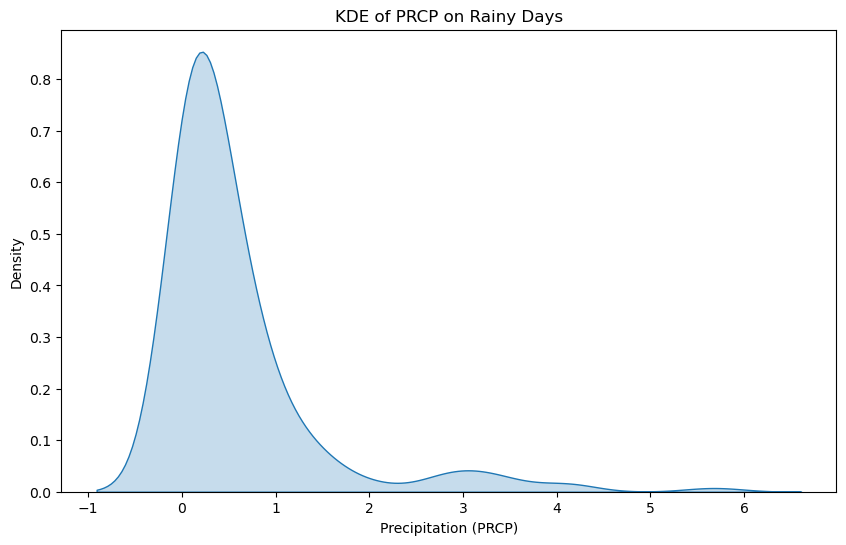

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

rainy_data = weather[weather['PRCP'] > 0]

# Plot KDE
plt.figure(figsize=(10, 6))
sns.kdeplot(data=rainy_data['PRCP'],fill=True)
plt.xlabel('Precipitation (PRCP)')
plt.ylabel('Density')
plt.title('KDE of PRCP on Rainy Days')
plt.show()

### Improvements

To improve the current model, I recognize the need to add higher-order states to the state space. Since weather persistence is often dependent on what occurred over several previous days and not just the day immediately prior, incorporating these higher-order states allows the model to capture those longer-term impacts. This adjustment will aid significantly in improving the accuracy of the transition predictions by using the history of several days, rather than relying solely on the most recent observation.

 The current dataset has significant gaps with missing dates throughout the observation period. Since weather is inherently sequential, these gaps break the temporal continuity necessary for accurate Markov modeling. Obtaining complete daily records would ensure proper sequential dependencies and eliminate the artificial transitions that currently occur across data gaps, making the model more reliable for forecasting real weather patterns.

4. Taxicab trajectories: Using the pickled taxicab data, we want to complete the exercise from class.

- For the taxicab trajectory data, determine your state space and clean your sequences of cab rides.
- Compute the transition matrix for the taxicab data between neighborhoods in Manhattan. Plot it in a heat map. What are the most common routes?
- Explain why taxicabs are most likely order 1, and not 2 or more.
- Starting at Hell's Kitchen, create a sequence of forecasts of where the cab is likely to be in 2, 3, 5, and 10 trips
- Starting at any neighborhood, iterate your forecast until it is no longer changing very much. Where do cabs spend most of their time working in Manhattan?

### State Space

In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import pickle

In [32]:
with open('taxicab.pkl', 'rb') as f:
    data = pickle.load(f)

len(data)


1000

In [33]:
data[0]

0     Outside Manhattan
0     Outside Manhattan
0     Outside Manhattan
0     Outside Manhattan
0     Outside Manhattan
            ...        
29                 SoHo
29                 SoHo
13    Greenwich Village
3               Chelsea
3               Chelsea
Name: nbhd, Length: 26026, dtype: object

In [34]:
states = set(data[0])
for i in range(1,len(data)):
    new_trip = data[i]
    new_states = set(new_trip)
    states = states.union(new_states)

states = list(states)
states.sort()
states

['Battery Park City',
 'Central Park',
 'Chelsea',
 'Chinatown',
 'Civic Center',
 'East Harlem',
 'East Village',
 'Ellis Island',
 'Financial District',
 'Flatiron District',
 'Governors Island',
 'Gramercy',
 'Greenwich Village',
 'Harlem',
 "Hell's Kitchen",
 'Inwood',
 'Kips Bay',
 'Liberty Island',
 'Little Italy',
 'Lower East Side',
 'Marble Hill',
 'Midtown',
 'Morningside Heights',
 'Murray Hill',
 'NoHo',
 'Nolita',
 'Outside Manhattan',
 "Randall's Island",
 'Roosevelt Island',
 'SoHo',
 'Stuyvesant Town',
 'Theater District',
 'Tribeca',
 'Two Bridges',
 'Upper East Side',
 'Upper West Side',
 'Washington Heights',
 'West Village']

### Transition Matrix

In [35]:
T = np.zeros((len(states), len(states)))
T

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [36]:
for trip in data:
    seq = np.array(trip)
    for t in range(1,len(seq)):
        # Current and next tokens:
        x_tm1 = seq[t-1] # previous state
        x_t = seq[t] # current state
        # Determine transition indices:
        index_from = states.index(x_tm1)
        index_to = states.index(x_t)
        # Update transition counts:
        T[index_to, index_from] += 1

In [37]:
tr_counts = T

Transition Counts:
 [[6.00930e+04 1.00500e+03 1.64200e+04 ... 5.38700e+03 1.42000e+02
  1.25610e+04]
 [6.05000e+02 5.22680e+04 1.09580e+04 ... 6.09840e+04 7.76000e+02
  3.02800e+03]
 [1.62140e+04 1.17050e+04 6.62397e+05 ... 6.61460e+04 2.48900e+03
  1.23919e+05]
 ...
 [4.14500e+03 8.18470e+04 6.63150e+04 ... 7.63963e+05 1.30390e+04
  2.07260e+04]
 [1.65000e+02 9.23000e+02 4.11000e+03 ... 1.28010e+04 1.12340e+04
  1.41200e+03]
 [1.38660e+04 3.24300e+03 1.22544e+05 ... 1.97780e+04 9.65000e+02
  2.42469e+05]]
[[2.292350e+05 3.701250e+05 1.978286e+06 1.058700e+05 5.791000e+04
  3.168450e+05 8.886410e+05 3.000000e+00 4.415730e+05 3.952900e+05
  1.200000e+01 5.017520e+05 5.102590e+05 2.171460e+05 1.224335e+06
  1.431100e+04 5.077810e+05 1.000000e+00 3.859100e+04 3.705730e+05
  4.930000e+02 3.851989e+06 1.627100e+05 6.544000e+05 1.743200e+05
  1.063810e+05 2.363902e+06 3.603000e+03 8.010000e+03 5.505930e+05
  1.112820e+05 8.740570e+05 4.086350e+05 1.038800e+04 2.797710e+06
  1.803502e+06 7.25

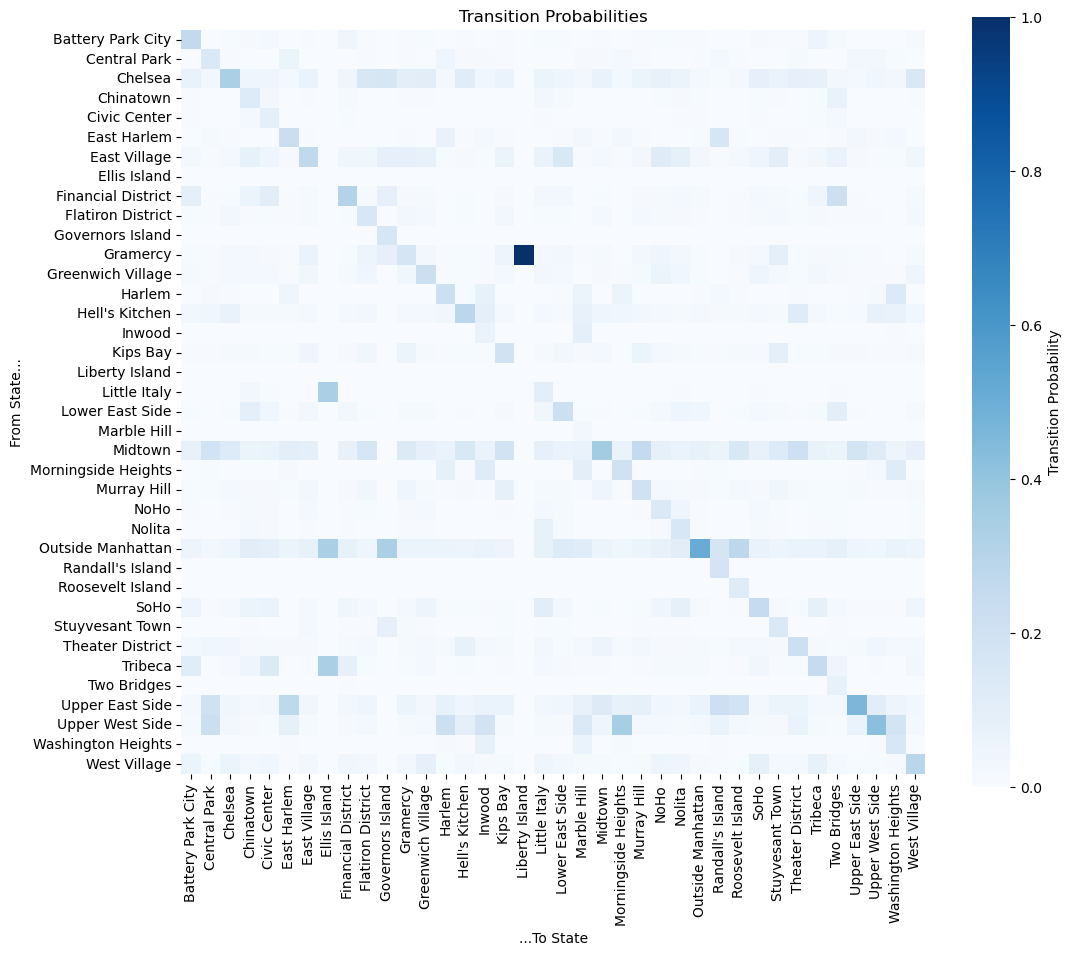

In [38]:
import matplotlib.pyplot as plt

print('Transition Counts:\n', tr_counts)
# Sum the transition counts by row:
sums = tr_counts.sum(axis=0, keepdims=True)
print(sums)

print('State proportions: \n')

# Normalize the transition count matrix to get proportions:
tr_pr = np.divide(tr_counts, sums, 
                             out=np.zeros_like(tr_counts), 
                             where=sums!=0)
print(tr_pr)
print('Transition Proportions:\n')

tr_df = pd.DataFrame(np.round(tr_pr,2), index=states, columns=states)
print(tr_df)

plt.figure(figsize=(12, 10))
sns.heatmap(tr_pr, 
            cmap='Blues',    
            square=True,          
            xticklabels=states,
            yticklabels=states,
            cbar_kws={'label': 'Transition Probability'})

plt.title('Transition Probabilities')
plt.xlabel('...To State')
plt.ylabel('From State...')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

### Common Routes

The heatmap shows that the most common patterns are self-loops, where taxicabs remain within the same neighborhood. This is especially frequent in Midtown, the Upper West Side, the Upper East Side, and areas Outside Manhattan. Cross-neighborhood trips reveal Midtown as a major hub, with strong connections to multiple areas across Manhattan. Trips to and from Outside Manhattan are also quite common, reflecting its large geographic coverage. The most frequent individual route appears to be between Gramercy and Liberty Island, as indicated by the darkest purple region on the heatmap.

### 1st Order
Taxicab trips are most likely Order 1 because the next destination depends on the current location rather than previous travel history. Each trip involves a different passenger making independent destination choices based on where they are now, not where the cab has been. Since consecutive trips have no meaningful connection - the passenger dropped off at Midtown doesn't influence where the next passenger goes - there's no memory between trips. Destination decisions are driven by the current geographic context alone, making higher-order models inappropriate for taxi data where each trip is an independent event.

### Hells Kitchen Forecasting 

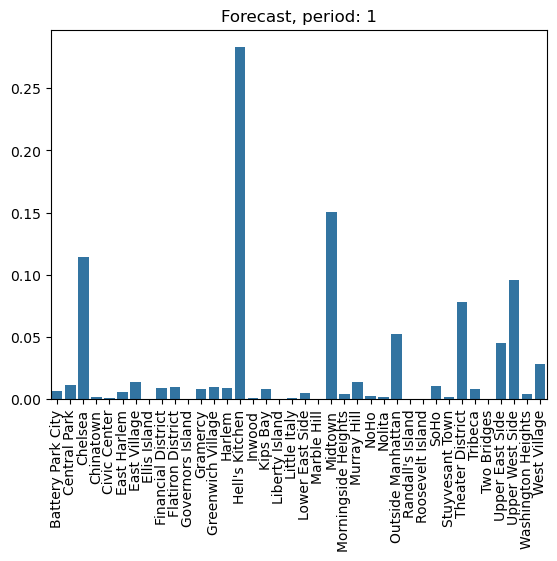

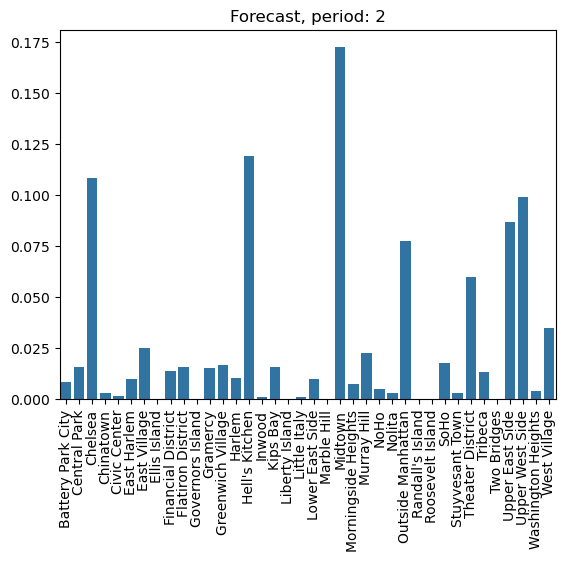

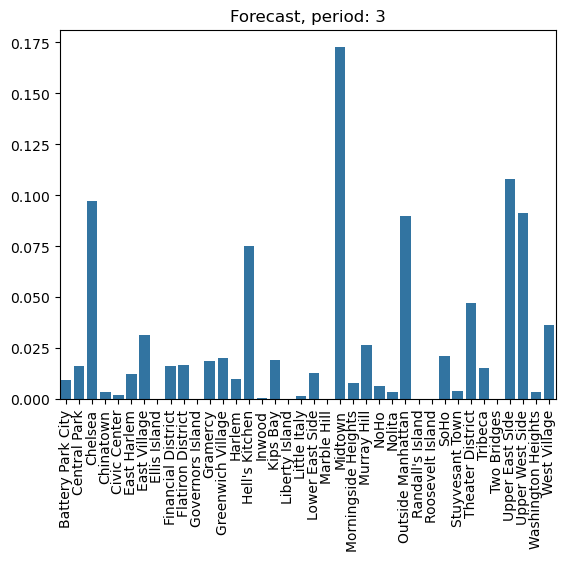

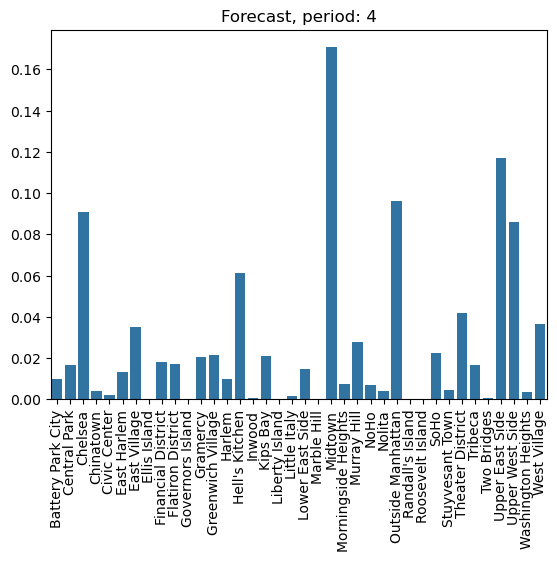

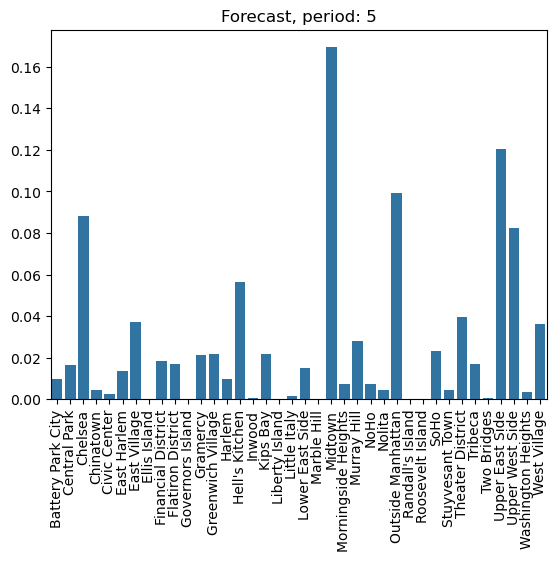

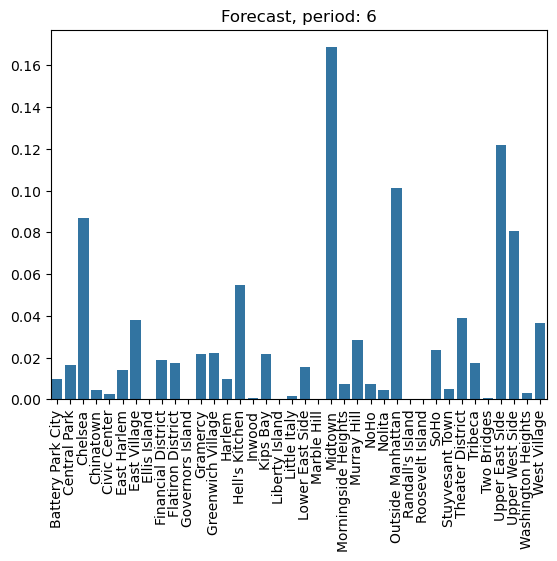

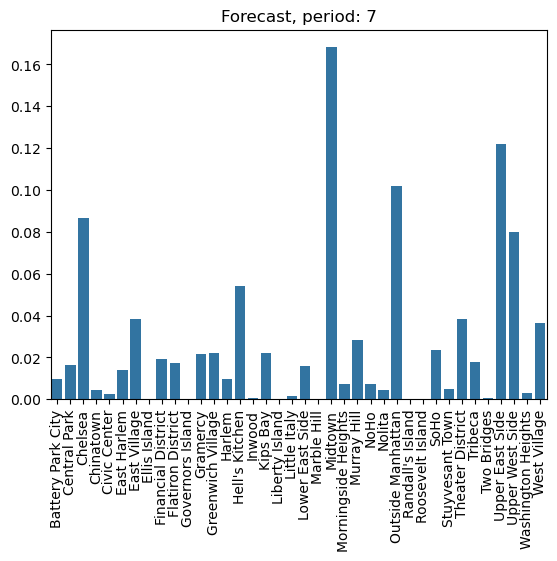

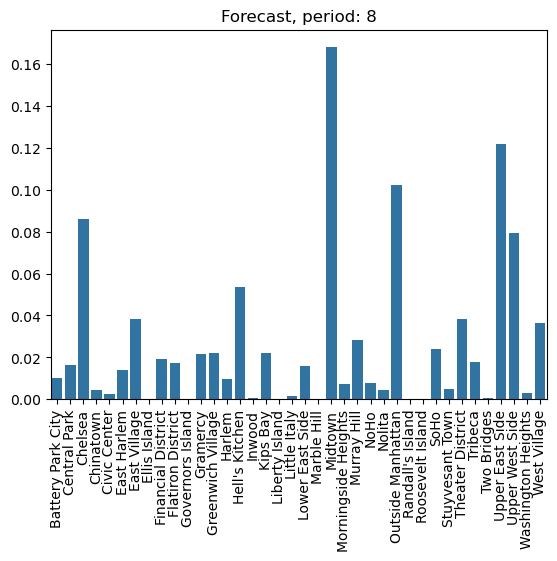

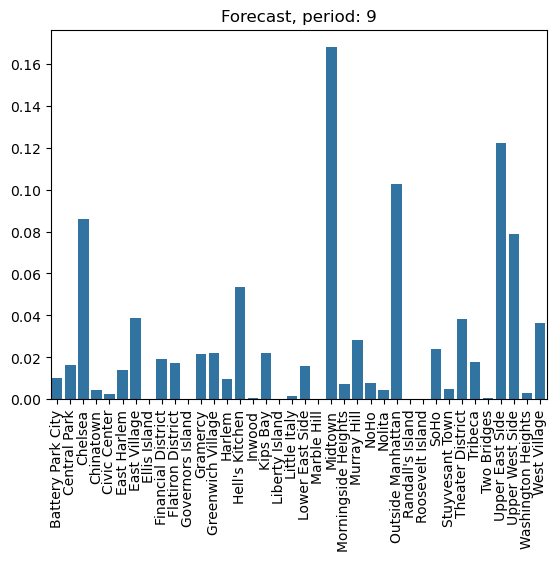

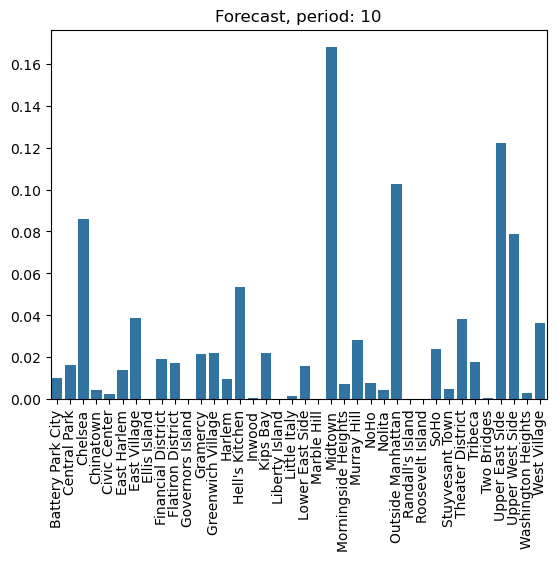

In [39]:
np.random.seed(100)

state_index = states.index("Hell's Kitchen") # Get the index of the initial state
##Initial density:
density = np.zeros(len(states))
density[state_index] = 1
n_sim = 10

forecast = ["Hell's Kitchen"]
for t in range(n_sim): 
    density = tr_pr @ density
    forecast.append(density) # Append new forecast
    sns.barplot(x=states,y=density).set(title=f'Forecast, period: {str(t+1)}')
    plt.xticks(rotation=90)
    plt.show()

### Any Neighborhood

In [40]:
 # Choose an initial state at random
state_index = states.index("East Harlem") # Get the index of the initial state

np.random.seed(100)
##Initial density:
density = np.zeros(len(states))
density[state_index] = 1
n_sim = 100
print(state_index)
results = []


forecast = ["East Harlem"]
for t in range(n_sim): 
    density = tr_pr @ density
    results.append(density)

df = pd.DataFrame(results, columns = states)
df

5


,Battery Park City,Central Park,Chelsea,Chinatown,Civic Center,East Harlem,East Village,Ellis Island,Financial District,Flatiron District,...,Roosevelt Island,SoHo,Stuyvesant Town,Theater District,Tribeca,Two Bridges,Upper East Side,Upper West Side,Washington Heights,West Village
0,0.001493,0.056618,0.020218,0.000849,0.000540,0.226994,0.012748,0.000000e+00,0.004011,0.004715,...,0.000243,0.003267,0.001856,0.013903,0.002515,0.000196,0.276328,0.087683,0.005283,0.006101
1,0.003974,0.037874,0.043444,0.002028,0.001218,0.068472,0.020268,6.012296e-08,0.008686,0.009527,...,0.000322,0.009101,0.002813,0.027368,0.006805,0.000254,0.237786,0.115383,0.004842,0.014684
2,0.006061,0.026925,0.061182,0.002919,0.001683,0.031205,0.026315,9.377262e-08,0.012354,0.012877,...,0.000344,0.014109,0.003514,0.034411,0.010483,0.000313,0.188499,0.110971,0.004185,0.022180
3,0.007528,0.021790,0.072247,0.003534,0.001991,0.020656,0.030755,1.100105e-07,0.014892,0.014826,...,0.000348,0.017720,0.004006,0.037255,0.013140,0.000361,0.158361,0.100831,0.003760,0.027614
4,0.008484,0.019237,0.078551,0.003940,0.002192,0.016969,0.033757,1.185376e-07,0.016551,0.015900,...,0.000349,0.020121,0.004329,0.038181,0.014913,0.000394,0.141858,0.092562,0.003510,0.031173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.009983,0.016119,0.086153,0.004611,0.002522,0.013799,0.038700,1.306526e-07,0.019232,0.017214,...,0.000349,0.023978,0.004846,0.038064,0.017796,0.000452,0.121839,0.078541,0.003159,0.036554
96,0.009983,0.016119,0.086153,0.004611,0.002522,0.013799,0.038700,1.306526e-07,0.019232,0.017214,...,0.000349,0.023978,0.004846,0.038064,0.017796,0.000452,0.121839,0.078541,0.003159,0.036554
97,0.009983,0.016119,0.086153,0.004611,0.002522,0.013799,0.038700,1.306526e-07,0.019232,0.017214,...,0.000349,0.023978,0.004846,0.038064,0.017796,0.000452,0.121839,0.078541,0.003159,0.036554
98,0.009983,0.016119,0.086153,0.004611,0.002522,0.013799,0.038700,1.306526e-07,0.019232,0.017214,...,0.000349,0.023978,0.004846,0.038064,0.017796,0.000452,0.121839,0.078541,0.003159,0.036554


In [41]:
# Grab row 50 from the forecast dataframe
row_50 = df.iloc[99].copy()

# Sort by Probability in descending order
row_50_sorted = row_50.sort_values( ascending=False)

row_50_df = pd.DataFrame({
    'State': row_50_sorted.index,
    'Probability (percent)': row_50_sorted.values * 100
}).reset_index(drop=True)

print(row_50_df)

                  State  Probability (percent)
0               Midtown              16.774781
1       Upper East Side              12.183853
2     Outside Manhattan              10.295151
3               Chelsea               8.615257
4       Upper West Side               7.854079
5        Hell's Kitchen               5.331827
6          East Village               3.870008
7      Theater District               3.806433
8          West Village               3.655382
9           Murray Hill               2.849836
10                 SoHo               2.397839
11    Greenwich Village               2.222163
12             Kips Bay               2.211318
13             Gramercy               2.185048
14   Financial District               1.923171
15              Tribeca               1.779634
16    Flatiron District               1.721372
17      Lower East Side               1.613813
18         Central Park               1.611871
19          East Harlem               1.379874
20    Battery

In [42]:
 # Choose an initial state at random
state_index = states.index("SoHo") # Get the index of the initial state

np.random.seed(100)
##Initial density:
density = np.zeros(len(states))
density[state_index] = 1
n_sim = 100
print(state_index)
results = []


forecast = ["SoHo"]
for t in range(n_sim): 
    density = tr_pr @ density
    results.append(density)

df2 = pd.DataFrame(results, columns = states)
df2

29


,Battery Park City,Central Park,Chelsea,Chinatown,Civic Center,East Harlem,East Village,Ellis Island,Financial District,Flatiron District,...,Roosevelt Island,SoHo,Stuyvesant Town,Theater District,Tribeca,Two Bridges,Upper East Side,Upper West Side,Washington Heights,West Village
0,0.015438,0.003182,0.085350,0.009403,0.005957,0.002352,0.049717,0.000000e+00,0.026617,0.016152,...,0.000125,0.251787,0.003467,0.019612,0.040740,0.000456,0.028108,0.017759,0.001048,0.088016
1,0.016367,0.007019,0.101490,0.008023,0.004497,0.005981,0.055192,1.107125e-07,0.028862,0.019177,...,0.000251,0.087358,0.005348,0.028657,0.034937,0.000612,0.058896,0.036004,0.001915,0.072765
2,0.014406,0.010208,0.099330,0.006572,0.003547,0.008828,0.050784,1.375364e-07,0.026206,0.019145,...,0.000308,0.045824,0.005657,0.033279,0.027716,0.000589,0.082318,0.050535,0.002422,0.056363
3,0.012655,0.012449,0.094799,0.005721,0.003077,0.010751,0.046284,1.407265e-07,0.023606,0.018576,...,0.000332,0.033173,0.005485,0.035603,0.023300,0.000542,0.097934,0.060803,0.002716,0.046996
4,0.011525,0.013898,0.091347,0.005247,0.002835,0.011969,0.043231,1.385743e-07,0.021839,0.018076,...,0.000342,0.028440,0.005268,0.036763,0.020855,0.000507,0.107678,0.067585,0.002892,0.042122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.009983,0.016119,0.086153,0.004611,0.002522,0.013799,0.038700,1.306526e-07,0.019232,0.017214,...,0.000349,0.023978,0.004846,0.038064,0.017796,0.000452,0.121839,0.078541,0.003159,0.036554
96,0.009983,0.016119,0.086153,0.004611,0.002522,0.013799,0.038700,1.306526e-07,0.019232,0.017214,...,0.000349,0.023978,0.004846,0.038064,0.017796,0.000452,0.121839,0.078541,0.003159,0.036554
97,0.009983,0.016119,0.086153,0.004611,0.002522,0.013799,0.038700,1.306526e-07,0.019232,0.017214,...,0.000349,0.023978,0.004846,0.038064,0.017796,0.000452,0.121839,0.078541,0.003159,0.036554
98,0.009983,0.016119,0.086153,0.004611,0.002522,0.013799,0.038700,1.306526e-07,0.019232,0.017214,...,0.000349,0.023978,0.004846,0.038064,0.017796,0.000452,0.121839,0.078541,0.003159,0.036554


In [43]:
# Grab row 50 from the forecast dataframe
row_50_2 = df2.iloc[99].copy()

# Sort by Probability in descending order
row_50_sorted_2 = row_50_2.sort_values( ascending=False)

row_50_df_2 = pd.DataFrame({
    'State': row_50_sorted_2.index,
    'Probability (percent)': row_50_sorted_2.values * 100
}).reset_index(drop=True)

print(row_50_df_2)

                  State  Probability (percent)
0               Midtown              16.774781
1       Upper East Side              12.183853
2     Outside Manhattan              10.295151
3               Chelsea               8.615257
4       Upper West Side               7.854079
5        Hell's Kitchen               5.331827
6          East Village               3.870008
7      Theater District               3.806433
8          West Village               3.655382
9           Murray Hill               2.849836
10                 SoHo               2.397839
11    Greenwich Village               2.222163
12             Kips Bay               2.211318
13             Gramercy               2.185048
14   Financial District               1.923171
15              Tribeca               1.779634
16    Flatiron District               1.721372
17      Lower East Side               1.613813
18         Central Park               1.611871
19          East Harlem               1.379874
20    Battery

Based on the steady-state distribution, taxicabs spend most of their time working in Midtown (16.8%), followed by the Upper East Side (12.2%) and Chelsea (8.6%). Note that 'Outside Manhattan' (10.3%) ranks third overall, but within Manhattan proper, cabs concentrate their activity in Midtown and the Upper East Side. This reflects the high demand in these commercial and residential hubs. 